# eICU Sepsis Mortality Prediction with Trajectory Modeling
Comparison of single-biomarker (lactate) vs multi-biomarker (lactate, WBC, platelets) trajectory features

## Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

sys.path.append(os.path.abspath('../../../'))
from traj_features.backends.bootstrap import BootstrapTrajPS, BootstrapConfig
from traj_features.backends.bayes.classify import pos_flags_from_traj, flags_from_traj

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")

✓ Imports successful


## Load Data

In [12]:
# Load merged trajectory probabilities for all biomarkers
dataset = pd.read_csv('../../../results/eicu/sepsis/sepsis_trajectory_probs.csv')
print(f"✓ Loaded merged dataset: {len(dataset):,} samples")
print(f"  Unique patients: {dataset['stay_id'].nunique():,}")
print(f"  Outcome rate: {dataset['target_septic_shock'].mean():.1%}")
print(f"  Columns: {len(dataset.columns)}")
print(f"\nTrajectory columns present:")
traj_cols = [col for col in dataset.columns if 'stable' in col or 'gradual' in col or 'rapid' in col or 'decline' in col]
for col in sorted(traj_cols):
    print(f"  {col}: {dataset[col].notna().sum():6,} non-missing")

# Load biomarker time series data for summary statistics
lactate_ts = pd.read_csv('../../../results/eicu/sepsis/lactate_timeseries.csv')
wbc_ts = pd.read_csv('../../../results/eicu/sepsis/wbc_timeseries.csv')
platelets_ts = pd.read_csv('../../../results/eicu/sepsis/platelets_timeseries.csv')

print(f"\n✓ Loaded biomarker time series:")
print(f"  Lactate:   {len(lactate_ts):,} measurements ({lactate_ts['stay_id'].nunique():,} patients)")
print(f"  WBC:       {len(wbc_ts):,} measurements ({wbc_ts['stay_id'].nunique():,} patients)")
print(f"  Platelets: {len(platelets_ts):,} measurements ({platelets_ts['stay_id'].nunique():,} patients)")


✓ Loaded merged dataset: 10,791 samples
  Unique patients: 4,308
  Outcome rate: 14.3%
  Columns: 76

Trajectory columns present:
  lactate_gradual:  3,745 non-missing
  lactate_rapid:  3,745 non-missing
  lactate_stable:  3,745 non-missing
  platelet_gradual:  6,049 non-missing
  platelet_rapid:  6,049 non-missing
  platelet_stable:  6,049 non-missing
  wbc_gradual:  5,975 non-missing
  wbc_rapid:  5,975 non-missing
  wbc_stable:  5,975 non-missing

✓ Loaded biomarker time series:
  Lactate:   33,400 measurements (4,308 patients)
  WBC:       66,851 measurements (4,305 patients)
  Platelets: 68,255 measurements (4,302 patients)


In [13]:
# Bootstrap trajectory probabilities (cached)
bootstrap_dir = '../../../results/eicu/sepsis'
os.makedirs(bootstrap_dir, exist_ok=True)

BOOTSTRAP_N = 200

def _load_or_compute_bootstrap(ts_df, biomarker, value_col, cfg, output_name):
    output_path = os.path.join(bootstrap_dir, output_name)
    if os.path.exists(output_path):
        boot_df = pd.read_csv(output_path)
    else:
        traj_input = ts_df[['stay_id', 'time_days', 'time_day', value_col]].copy()
        traj_input = traj_input.rename(columns={'stay_id': 'patientid', value_col: 'lab_value'})
        traj_input = traj_input.dropna(subset=['lab_value']).sort_values(by=['patientid', 'time_days'])

        model = BootstrapTrajPS(BootstrapConfig(
            window_years=cfg['window_days'],
            n_bootstrap=cfg.get('n_bootstrap', BOOTSTRAP_N),
            smoothing=None,
            min_points_per_window=4,
            grid_freq=2,
            flat_thr=cfg['flat_thr'],
            decline_thr=cfg['decline_thr'],
            nonlinear_gap=cfg['nonlinear_gap'],
            pids='patientid',
            values='lab_value',
            time_col='time_days',
            windowing_col='time_day',
            n_jobs=-1,
            traj_types=cfg['traj_types'],
            class_func=cfg['class_func'],
            label_map=cfg['label_map'],
            progressbar=False
        ))
        boot_df = model.embed(traj_input)
        boot_df = boot_df.rename(columns={'patientid': 'stay_id'})
        boot_df.to_csv(output_path, index=False)

    if 'patientid' in boot_df.columns:
        boot_df = boot_df.rename(columns={'patientid': 'stay_id'})

    rename_map = {
        f"trajtype_{cfg['traj_types'][0]}_prob": f"{biomarker}_stable_boot",
        f"trajtype_{cfg['traj_types'][1]}_prob": f"{biomarker}_gradual_boot",
        f"trajtype_{cfg['traj_types'][2]}_prob": f"{biomarker}_rapid_boot",
    }
    for src in rename_map:
        if src not in boot_df.columns:
            boot_df[src] = np.nan
    boot_df = boot_df.rename(columns=rename_map)
    return boot_df[['stay_id', 'time_day'] + list(rename_map.values())]

bootstrap_configs = {
    'lactate': {
        'value_col': 'lactate',
        'flat_thr': 0.1,
        'decline_thr': 0.3,
        'nonlinear_gap': 0.5,
        'class_func': pos_flags_from_traj,
        'traj_types': ('stable', 'gradual_increase', 'rapid_increase'),
        'label_map': {'nonprogression': 'stable', 'linear': 'gradual_increase', 'nonlinear': 'rapid_increase'},
        'window_days': 3.0,
    },
    'wbc': {
        'value_col': 'wbc',
        'flat_thr': 1.0,
        'decline_thr': 3.0,
        'nonlinear_gap': 2.0,
        'class_func': pos_flags_from_traj,
        'traj_types': ('stable', 'gradual_increase', 'rapid_increase'),
        'label_map': {'nonprogression': 'stable', 'linear': 'gradual_increase', 'nonlinear': 'rapid_increase'},
        'window_days': 3.0,
    },
    'platelet': {
        'value_col': 'platelet',
        'flat_thr': -20.0,
        'decline_thr': -50.0,
        'nonlinear_gap': 30.0,
        'class_func': flags_from_traj,
        'traj_types': ('stable', 'gradual_decline', 'rapid_decline'),
        'label_map': {'nonprogression': 'stable', 'linear': 'gradual_decline', 'nonlinear': 'rapid_decline'},
        'window_days': 3.0,
    },
}

lactate_boot = _load_or_compute_bootstrap(
    lactate_ts, 'lactate', 'lactate', bootstrap_configs['lactate'], 'lactate_trajectory_probs_bootstrap.csv'
 )
wbc_boot = _load_or_compute_bootstrap(
    wbc_ts, 'wbc', 'wbc', bootstrap_configs['wbc'], 'wbc_trajectory_probs_bootstrap.csv'
 )
platelet_boot = _load_or_compute_bootstrap(
    platelets_ts, 'platelet', 'platelet', bootstrap_configs['platelet'], 'platelets_trajectory_probs_bootstrap.csv'
 )

dataset = dataset.merge(lactate_boot, on=['stay_id', 'time_day'], how='left')
dataset = dataset.merge(wbc_boot, on=['stay_id', 'time_day'], how='left')
dataset = dataset.merge(platelet_boot, on=['stay_id', 'time_day'], how='left')

print('✓ Added bootstrap trajectory probabilities')

✓ Added bootstrap trajectory probabilities


## Feature Engineering - Derived Trajectory Features

In [14]:
platelets_ts.columns

Index(['stay_id', 'lab_time_hours', 'labname', 'platelet', 'time_days',
       'time_day'],
      dtype='object')

In [15]:
# Generate summary statistics from biomarker time series (matching trajectory lookback window)
LOOKBACK_DAYS = 3  # Same as trajectory modeling window

def biomarker_summary_stats(ts_df, value_col, stay_id_col='stay_id', lookback_days=3):
    """
    Compute summary statistics from biomarker time series over a lookback window.
    Matches the pattern from MIMIC sepsis analysis.
    """
    summary_df_list = []
    for group, group_df in ts_df.groupby(stay_id_col):
        group_df = group_df.sort_values('time_days')
        summary_list = []
        for current_time in group_df['time_day'].unique():
            window_start = current_time - lookback_days
            window_data = group_df[
                group_df['time_day'].between(window_start, current_time, inclusive='both')
            ]
            if len(window_data) > 0:
                value_mean = window_data[value_col].mean()
                value_max = window_data[value_col].max()
                value_min = window_data[value_col].min()
                value_change = window_data[value_col].iloc[-1] - window_data[value_col].iloc[0]
                value_linear_trend = np.polyfit(window_data['time_days'], window_data[value_col], 1)[0] if len(window_data) > 1 else 0
                value_std = window_data[value_col].std() if len(window_data) > 1 else 0
            else:
                value_mean = np.nan
                value_max = np.nan
                value_min = np.nan
                value_change = np.nan
                value_linear_trend = np.nan
                value_std = np.nan
            summary_list.append({
                stay_id_col: group,
                'time_day': current_time,
                f'{value_col}_mean_{lookback_days}d': value_mean,
                f'{value_col}_max_{lookback_days}d': value_max,
                f'{value_col}_min_{lookback_days}d': value_min,
                f'{value_col}_change_{lookback_days}d': value_change,
                f'{value_col}_trend_{lookback_days}d': value_linear_trend,
                f'{value_col}_std_{lookback_days}d': value_std
            })
        summary_df_list.append(pd.DataFrame(summary_list))
    return pd.concat(summary_df_list, ignore_index=True)

print(f"Computing summary statistics (lookback={LOOKBACK_DAYS} days)...")
lactate_summary = biomarker_summary_stats(lactate_ts, 'lactate', lookback_days=LOOKBACK_DAYS)
wbc_summary = biomarker_summary_stats(wbc_ts, 'wbc', lookback_days=LOOKBACK_DAYS)
platelets_summary = biomarker_summary_stats(platelets_ts, 'platelet', lookback_days=LOOKBACK_DAYS)

print(f"\n✓ Generated summary statistics:")
print(f"  Lactate:   {len(lactate_summary):,} timepoints, {lactate_summary.columns.tolist()[2:]}")
print(f"  WBC:       {len(wbc_summary):,} timepoints")
print(f"  Platelets: {len(platelets_summary):,} timepoints")

# Merge summary statistics with main dataset
dataset = dataset.merge(lactate_summary, on=['stay_id', 'time_day'], how='left')
dataset = dataset.merge(wbc_summary, on=['stay_id', 'time_day'], how='left')
dataset = dataset.merge(platelets_summary, on=['stay_id', 'time_day'], how='left')

print(f"\n✓ Merged summary statistics: {len(dataset):,} samples, {len(dataset.columns)} columns")

# Create derived worsening features from trajectory probabilities
dataset['lactate_worsening'] = dataset['lactate_gradual'] + dataset['lactate_rapid']
dataset['wbc_worsening'] = dataset['wbc_gradual'] + dataset['wbc_rapid']
dataset['platelet_worsening'] = dataset['platelet_gradual'] + dataset['platelet_rapid']

# Aggregate worsening features
dataset['single_marker_max_worsening'] = dataset[['lactate_worsening', 'wbc_worsening', 'platelet_worsening']].max(axis=1)
dataset['multi_marker_mean_worsening'] = dataset[['lactate_worsening', 'wbc_worsening', 'platelet_worsening']].mean(axis=1)
dataset['n_markers_worsening'] = (dataset[['lactate_worsening', 'wbc_worsening', 'platelet_worsening']] > 0.5).sum(axis=1)

# Bootstrap-derived worsening features
if {'lactate_gradual_boot', 'lactate_rapid_boot'}.issubset(dataset.columns):
    dataset['lactate_worsening_boot'] = dataset['lactate_gradual_boot'] + dataset['lactate_rapid_boot']
if {'wbc_gradual_boot', 'wbc_rapid_boot'}.issubset(dataset.columns):
    dataset['wbc_worsening_boot'] = dataset['wbc_gradual_boot'] + dataset['wbc_rapid_boot']
if {'platelet_gradual_boot', 'platelet_rapid_boot'}.issubset(dataset.columns):
    dataset['platelet_worsening_boot'] = dataset['platelet_gradual_boot'] + dataset['platelet_rapid_boot']
if {'lactate_worsening_boot', 'wbc_worsening_boot', 'platelet_worsening_boot'}.issubset(dataset.columns):
    dataset['single_marker_max_worsening_boot'] = dataset[['lactate_worsening_boot', 'wbc_worsening_boot', 'platelet_worsening_boot']].max(axis=1)
    dataset['multi_marker_mean_worsening_boot'] = dataset[['lactate_worsening_boot', 'wbc_worsening_boot', 'platelet_worsening_boot']].mean(axis=1)
    dataset['n_markers_worsening_boot'] = (dataset[['lactate_worsening_boot', 'wbc_worsening_boot', 'platelet_worsening_boot']] > 0.5).sum(axis=1)

print(f"\n✓ Created derived worsening features:")
print(f"  lactate_worsening:           {dataset['lactate_worsening'].notna().sum():6,} non-missing")
print(f"  wbc_worsening:               {dataset['wbc_worsening'].notna().sum():6,} non-missing")
print(f"  platelet_worsening:          {dataset['platelet_worsening'].notna().sum():6,} non-missing")
print(f"  single_marker_max_worsening: {dataset['single_marker_max_worsening'].notna().sum():6,} non-missing")
print(f"  multi_marker_mean_worsening: {dataset['multi_marker_mean_worsening'].notna().sum():6,} non-missing")
print(f"  n_markers_worsening:         {dataset['n_markers_worsening'].notna().sum():6,} non-missing")

Computing summary statistics (lookback=3 days)...

✓ Generated summary statistics:
  Lactate:   16,062 timepoints, ['lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d', 'lactate_change_3d', 'lactate_trend_3d', 'lactate_std_3d']
  WBC:       50,985 timepoints
  Platelets: 51,113 timepoints

✓ Merged summary statistics: 10,791 samples, 103 columns

✓ Created derived worsening features:
  lactate_worsening:            3,745 non-missing
  wbc_worsening:                5,975 non-missing
  platelet_worsening:           6,049 non-missing
  single_marker_max_worsening:  7,375 non-missing
  multi_marker_mean_worsening:  7,375 non-missing
  n_markers_worsening:         10,791 non-missing


In [16]:
# Check available static and dynamic features
print("Available columns in dataset:")
print("\nStatic features:")
static_candidates = ['age', 'gender']
for col in static_candidates:
    if col in dataset.columns:
        print(f"  {col}: {dataset[col].notna().sum():6,} non-missing")

print("\nDynamic lab features (min/mean/max):")
lab_features = []
for prefix in ['min_', 'mean_', 'max_']:
    lab_cols = [col for col in dataset.columns if col.startswith(prefix) and 'lactate' not in col and 'wbc' not in col and 'platelet' not in col]
    if lab_cols:
        print(f"\n  {prefix}* features: {len(lab_cols)} columns")
        for col in sorted(lab_cols)[:5]:  # Show first 5
            print(f"    {col}")
        if len(lab_cols) > 5:
            print(f"    ... and {len(lab_cols)-5} more")
        lab_features.extend(lab_cols)

print("\nDynamic vital features:")
vital_candidates = [col for col in dataset.columns if any(x in col for x in ['heart_rate', 'respiratory_rate', 'o2_sat', 'systolic', 'diastolic', 'mean_bp', 'temperature'])]
for col in sorted(vital_candidates)[:10]:
    print(f"  {col}")
if len(vital_candidates) > 10:
    print(f"  ... and {len(vital_candidates)-10} more")


Available columns in dataset:

Static features:
  age: 10,791 non-missing
  gender: 10,791 non-missing

Dynamic lab features (min/mean/max):

  min_* features: 12 columns
    min_BUN
    min_PT
    min_albumin
    min_anion gap
    min_bicarbonate
    ... and 7 more

  mean_* features: 15 columns
    mean_BUN
    mean_PT
    mean_albumin
    mean_anion gap
    mean_bicarbonate
    ... and 10 more

  max_* features: 12 columns
    max_BUN
    max_PT
    max_albumin
    max_anion gap
    max_bicarbonate
    ... and 7 more

Dynamic vital features:
  diastolic_max
  diastolic_mean
  diastolic_min
  heart_rate_max
  heart_rate_mean
  heart_rate_min
  mean_bp_max
  mean_bp_mean
  mean_bp_min
  o2_sat_max
  ... and 8 more


## Define Feature Sets (with Derived Features)

## Exploratory Data Analysis

In [17]:
# Biomarker trajectory statistics
print("Lactate Trajectories:")
for col in ['lactate_stable', 'lactate_gradual', 'lactate_rapid']:
    non_missing = dataset[col].notna().sum()
    print(f"  {col:20s}: {non_missing:6,} ({100*non_missing/len(dataset):5.1f}%)")

print("\nWBC Trajectories:")
for col in ['wbc_stable', 'wbc_gradual', 'wbc_rapid']:
    non_missing = dataset[col].notna().sum()
    print(f"  {col:20s}: {non_missing:6,} ({100*non_missing/len(dataset):5.1f}%)")

print("\nPlatelet Trajectories:")
for col in ['platelet_stable', 'platelet_gradual', 'platelet_rapid']:
    non_missing = dataset[col].notna().sum()
    print(f"  {col:20s}: {non_missing:6,} ({100*non_missing/len(dataset):5.1f}%)")

# Check correlation between biomarkers
print("\n\nCorrelation between biomarker 'stable' probabilities (where data available):")
lactate_cols = ['lactate_stable', 'lactate_gradual', 'lactate_rapid']
wbc_cols = ['wbc_stable', 'wbc_gradual', 'wbc_rapid']
platelet_cols = ['platelet_stable', 'platelet_gradual', 'platelet_rapid']

subset = dataset[lactate_cols + wbc_cols + platelet_cols].dropna()
print(f"Samples with all biomarker data: {len(subset):,}")

if len(subset) > 0:
    corr = subset[['lactate_stable', 'wbc_stable', 'platelet_stable']].corr()
    print("\nCorrelation matrix (stable probabilities):")
    print(corr.round(3))

Lactate Trajectories:
  lactate_stable      :  3,745 ( 34.7%)
  lactate_gradual     :  3,745 ( 34.7%)
  lactate_rapid       :  3,745 ( 34.7%)

WBC Trajectories:
  wbc_stable          :  5,975 ( 55.4%)
  wbc_gradual         :  5,975 ( 55.4%)
  wbc_rapid           :  5,975 ( 55.4%)

Platelet Trajectories:
  platelet_stable     :  6,049 ( 56.1%)
  platelet_gradual    :  6,049 ( 56.1%)
  platelet_rapid      :  6,049 ( 56.1%)


Correlation between biomarker 'stable' probabilities (where data available):
Samples with all biomarker data: 2,403

Correlation matrix (stable probabilities):
                 lactate_stable  wbc_stable  platelet_stable
lactate_stable            1.000       0.195            0.185
wbc_stable                0.195       1.000            0.125
platelet_stable           0.185       0.125            1.000


## Define Feature Sets

Two comparison strategies:
1. **Lactate Only** - Single biomarker (baseline)
2. **All Biomarkers** - Multi-biomarker (lactate + WBC + platelets)

In [18]:
# Define comprehensive feature sets (matching MIMIC sepsis framework exactly)

# Biomarker trajectory columns
lactate_traj = ['lactate_stable', 'lactate_gradual', 'lactate_rapid', 'lactate_worsening']
wbc_traj = ['wbc_stable', 'wbc_gradual', 'wbc_rapid', 'wbc_worsening']
platelet_traj = ['platelet_stable', 'platelet_gradual', 'platelet_rapid', 'platelet_worsening']

# Bootstrap trajectory columns
lactate_traj_boot = [c for c in ['lactate_stable_boot', 'lactate_gradual_boot', 'lactate_rapid_boot', 'lactate_worsening_boot'] if c in dataset.columns]
wbc_traj_boot = [c for c in ['wbc_stable_boot', 'wbc_gradual_boot', 'wbc_rapid_boot', 'wbc_worsening_boot'] if c in dataset.columns]
platelet_traj_boot = [c for c in ['platelet_stable_boot', 'platelet_gradual_boot', 'platelet_rapid_boot', 'platelet_worsening_boot'] if c in dataset.columns]

# Multi-marker worsening score
multi_marker_worsening = ['multi_marker_mean_worsening']
multi_marker_worsening_boot = [c for c in ['multi_marker_mean_worsening_boot'] if c in dataset.columns]

# Summary statistics (3-day lookback)
lactate_summary = ['lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
                   'lactate_change_3d', 'lactate_trend_3d', 'lactate_std_3d']
wbc_summary = ['wbc_mean_3d', 'wbc_max_3d', 'wbc_min_3d',
               'wbc_change_3d', 'wbc_trend_3d', 'wbc_std_3d']
platelet_summary = ['platelet_mean_3d', 'platelet_max_3d', 'platelet_min_3d',
                    'platelet_change_3d', 'platelet_trend_3d', 'platelet_std_3d']

# Static features
static_features = []
if 'age' in dataset.columns:
    static_features.append('age')
if 'gender' in dataset.columns:
    static_features.append('gender')

# Dynamic features: vitals and labs (excluding trajectory biomarkers)
exclude_keywords = ['3d', 'stable', 'gradual', 'rapid', 'worsening', 'marker', 'trend', 'change', 'boot']
dynamic_labs = [col for col in dataset.columns 
                if any(col.startswith(prefix) for prefix in ['min_', 'mean_', 'max_']) 
                and not any(keyword in col.lower() for keyword in exclude_keywords)]
dynamic_vitals = [col for col in dataset.columns 
                  if any(x in col for x in ['heart_rate', 'respiratory_rate', 'o2_sat', 
                                             'systolic', 'diastolic', 'mean_bp', 'temperature'])]
dynamic_features = dynamic_labs + dynamic_vitals
static_dynamic_cols = static_features + dynamic_features

print(f"Feature inventory:")
print(f"  Lactate trajectories:          {len(lactate_traj)} features")
print(f"  WBC trajectories:              {len(wbc_traj)} features")
print(f"  Platelets trajectories:        {len(platelet_traj)} features")
print(f"  Multi-marker worsening:        {len(multi_marker_worsening)} features")
print(f"  Lactate trajectories (boot):   {len(lactate_traj_boot)} features")
print(f"  WBC trajectories (boot):       {len(wbc_traj_boot)} features")
print(f"  Platelets trajectories (boot): {len(platelet_traj_boot)} features")
print(f"  Lactate summary stats:         {len(lactate_summary)} features")
print(f"  WBC summary stats:             {len(wbc_summary)} features")
print(f"  Platelets summary stats:       {len(platelet_summary)} features")
print(f"  Static features:               {len(static_features)} features")
print(f"  Dynamic labs:                  {len(dynamic_labs)} features")
print(f"  Dynamic vitals:                {len(dynamic_vitals)} features")

# Feature sets matching MIMIC sepsis framework
feature_sets = {
    # 1. Trajectory only (lactate vs multi-marker)
    'Lactate Trajectory Only': lactate_traj,
    
    'Multi-Marker Trajectories': (
        lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening
    ),
    
    'Lactate Trajectory Only (Bootstrap)': lactate_traj_boot,
    
    'Multi-Marker Trajectories (Bootstrap)': (
        lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot
    ),
    
    # 2. Summary stats only (lactate vs multi-marker)
    'Lactate Summary Stats Only': lactate_summary,
    
    'Multi-Marker Summary Stats': (
        lactate_summary + wbc_summary + platelet_summary
    ),
    
    # 3. Trajectory + Summary (lactate vs multi-marker)
    'Lactate Trajectory + Summary Stats': (
        lactate_traj + lactate_summary
    ),
    
    'Multi-Marker Trajectories + Summary Stats': (
        lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening +
        lactate_summary + wbc_summary + platelet_summary
    ),
    
    'Lactate Trajectory + Summary Stats (Bootstrap)': (
        lactate_traj_boot + lactate_summary
    ),
    
    'Multi-Marker Trajectories + Summary Stats (Bootstrap)': (
        lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot +
        lactate_summary + wbc_summary + platelet_summary
    ),
    
    # 4. Static only
    'Static Only': static_features,
    
    # 5. Static + Trajectory (lactate vs multi-marker)
    'Static + Lactate Trajectory': (
        static_features + lactate_traj
    ),
    
    'Static + Multi-Marker Trajectories': (
        static_features + lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening
    ),
    
    'Static + Lactate Trajectory (Bootstrap)': (
        static_features + lactate_traj_boot
    ),
    
    'Static + Multi-Marker Trajectories (Bootstrap)': (
        static_features + lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot
    ),
    
    # 6. Static + Summary (lactate vs multi-marker)
    'Static + Lactate Summary Stats': (
        static_features + lactate_summary
    ),
    
    'Static + Multi-Marker Summary Stats': (
        static_features + lactate_summary + wbc_summary + platelet_summary
    ),
}

# Filter feature sets to remove unavailable columns
for set_name, cols in list(feature_sets.items()):
    available = [c for c in cols if c in dataset.columns]
    removed = [c for c in cols if c not in dataset.columns]
    if removed:
        print(f"Feature set '{set_name}': removed {len(removed)} missing columns: {removed}")
    feature_sets[set_name] = available

# Add dynamic feature combinations
if len(dynamic_features) > 0:
    feature_sets['Static + Dynamic'] = [c for c in static_dynamic_cols if c in dataset.columns]
    
    feature_sets['Static + Dynamic + Lactate Trajectory'] = [c for c in static_dynamic_cols + lactate_traj if c in dataset.columns]
    feature_sets['Static + Dynamic + Lactate Trajectory (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot if c in dataset.columns]
    
    feature_sets['Static + Dynamic + Multi-Marker Trajectories'] = [c for c in static_dynamic_cols + lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening if c in dataset.columns]
    feature_sets['Static + Dynamic + Multi-Marker Trajectories (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot if c in dataset.columns]
    
    feature_sets['Static + Dynamic + Lactate Summary Stats'] = [c for c in static_dynamic_cols + lactate_summary if c in dataset.columns]
    feature_sets['Static + Dynamic + Multi-Marker Summary Stats'] = [c for c in static_dynamic_cols + lactate_summary + wbc_summary + platelet_summary if c in dataset.columns]
    
    feature_sets['Static + Dynamic + Lactate Trajectory + Summary Stats'] = [c for c in static_dynamic_cols + lactate_traj + lactate_summary if c in dataset.columns]
    feature_sets['Static + Dynamic + Lactate Trajectory + Summary Stats (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot + lactate_summary if c in dataset.columns]
    
    feature_sets['Static + Dynamic + Multi-Marker Trajectories + Summary Stats'] = [c for c in static_dynamic_cols + lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening + lactate_summary + wbc_summary + platelet_summary if c in dataset.columns]
    feature_sets['Static + Dynamic + Multi-Marker Trajectories + Summary Stats (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot + lactate_summary + wbc_summary + platelet_summary if c in dataset.columns]

print(f"\n\nComprehensive Feature Sets ({len(feature_sets)} total):")
for name, features in feature_sets.items():
    print(f"  {name:70s}: {len(features):3d} features")

Feature inventory:
  Lactate trajectories:          4 features
  WBC trajectories:              4 features
  Platelets trajectories:        4 features
  Multi-marker worsening:        1 features
  Lactate trajectories (boot):   4 features
  WBC trajectories (boot):       4 features
  Platelets trajectories (boot): 4 features
  Lactate summary stats:         6 features
  WBC summary stats:             6 features
  Platelets summary stats:       6 features
  Static features:               2 features
  Dynamic labs:                  42 features
  Dynamic vitals:                18 features


Comprehensive Feature Sets (28 total):
  Lactate Trajectory Only                                               :   4 features
  Multi-Marker Trajectories                                             :  13 features
  Lactate Trajectory Only (Bootstrap)                                   :   4 features
  Multi-Marker Trajectories (Bootstrap)                                 :  13 features
  Lactate Summary 

## Train Models

In [19]:
# Convert gender to binary (M=1, F=0)
if 'gender' in dataset.columns:
    gender_map = {'M': 1, 'F': 0}
    dataset['gender'] = dataset['gender'].map(gender_map)
    print(f"Converted gender to binary: M=1, F=0")
    print(f"  Missing gender: {dataset['gender'].isna().sum()}")

# Separate trajectory and summary features for different imputation strategies
trajectory_cols = []  # stable, gradual, rapid, worsening
summary_cols = []     # mean_, max_, min_, change_, trend_, std_

for col in dataset.columns:
    if any(biomarker in col for biomarker in ['lactate', 'wbc', 'platelet']):
        if any(keyword in col for keyword in ['stable', 'gradual', 'rapid', 'worsening']):
            trajectory_cols.append(col)
        elif '3d' in col:
            summary_cols.append(col)

print(f"\nImputing features:")
print(f"  Trajectory features: {len(trajectory_cols)} columns (ffill(limit=2).fillna(0))")
print(f"  Summary features: {len(summary_cols)} columns (fillna(0))")

print(f"\nBefore imputation - missing:")
print(f"  Trajectory: {dataset[trajectory_cols].isna().sum().sum():,}")
print(f"  Summary: {dataset[summary_cols].isna().sum().sum():,}")

# Impute trajectory features: forward-fill up to 2 steps
dataset[trajectory_cols] = dataset.groupby('stay_id')[trajectory_cols].ffill(limit=2)



print(f"\nAfter imputation - missing:")
print(f"  Trajectory: {dataset[trajectory_cols].isna().sum().sum():,}")
print(f"  Summary: {dataset[summary_cols].isna().sum().sum():,}")

# Prepare for modeling
dataset_clean = dataset.dropna(subset=['target_septic_shock'])
y = dataset_clean['target_septic_shock']
groups = dataset_clean['stay_id']

print(f"\nDataset: {len(y):,} samples, {y.sum():,} events ({100*y.mean():.1f}%)")
print(f"Unique patients: {groups.nunique():,}")


Converted gender to binary: M=1, F=0
  Missing gender: 10791

Imputing features:
  Trajectory features: 24 columns (ffill(limit=2).fillna(0))
  Summary features: 18 columns (fillna(0))

Before imputation - missing:
  Trajectory: 132,832
  Summary: 31,038

After imputation - missing:
  Trajectory: 122,080
  Summary: 31,038

Dataset: 10,791 samples, 1,548 events (14.3%)
Unique patients: 4,308


In [20]:
# Define models to compare
models_to_evaluate = {
    'XGBoost': lambda pos_weight, seed: XGBClassifier(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        random_state=seed,
        eval_metric='logloss'
    ),
    'Logistic Regression': lambda pos_weight, seed: LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=seed,
        solver='lbfgs'
    ),
    'Random Forest': lambda pos_weight, seed: RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=seed,
        n_jobs=4
    ),
    'Gradient Boosting': lambda pos_weight, seed: HistGradientBoostingClassifier(
        max_bins=225,
        max_depth=3,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=seed
    )
}

# Cross-validation - ALL FEATURE SETS with ALL MODELS
n_repeats = 10
n_folds = 5
results = {model_name: {} for model_name in models_to_evaluate.keys()}

print(f"\nTraining ALL FEATURE SETS ({n_repeats}-Repeat {n_folds}-Fold CV with {len(models_to_evaluate)} models):\n")

for model_name, model_fn in models_to_evaluate.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)

    dataset_model = dataset_clean.copy()
    # zfill traj and summary features for none-boosting models
    if model_name not in ['XGBoost', 'Gradient Boosting']:
        dataset_model[traj_cols] = dataset_model[traj_cols].fillna(0)
        dataset_model[summary_cols] = dataset_model[summary_cols].fillna(0)
    
    for feature_set_name, feature_cols in feature_sets.items():
        print(f"{feature_set_name}...")
        
        fold_metrics = {'roc_auc': [], 'avg_precision': [], 'y_true': [], 'y_pred': []}
        
        for repeat in range(n_repeats):
            # Shuffle dataset for this repeat to get different fold randomizations
            shuffle_idx = np.random.RandomState(seed=920+repeat).permutation(len(dataset_model))
            dataset_repeat = dataset_model.iloc[shuffle_idx].reset_index(drop=True)
            y_repeat = y.iloc[shuffle_idx].reset_index(drop=True)
            groups_repeat = groups.iloc[shuffle_idx].reset_index(drop=True)
            
            gkf = GroupKFold(n_splits=n_folds)
            
            for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(dataset_repeat, y_repeat, groups_repeat)):
                X_train = dataset_repeat.iloc[train_idx][feature_cols]
                X_test = dataset_repeat.iloc[test_idx][feature_cols]
                y_train = y_repeat.iloc[train_idx]
                y_test = y_repeat.iloc[test_idx]
                
                if model_name not in ['XGBoost', 'Gradient Boosting']:
                    # Impute missing values using training data (prevents leakage)
                    imputer = SimpleImputer(strategy='median')
                    X_train_imputed = imputer.fit_transform(X_train)
                    X_test_imputed = imputer.transform(X_test)
                
                else:
                    # For boosting models, we already filled missing values with 0
                    X_train_imputed = X_train
                    X_test_imputed = X_test
                
                # Scale features
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_imputed)
                X_test_scaled = scaler.transform(X_test_imputed)
                
                # Train model
                scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
                model = model_fn(scale_pos_weight, 920+repeat)
                model.fit(X_train_scaled, y_train)
                
                # Predict
                y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
                
                # Metrics
                fold_metrics['roc_auc'].append(roc_auc_score(y_test, y_pred_proba))
                fold_metrics['avg_precision'].append(average_precision_score(y_test, y_pred_proba))
                fold_metrics['y_true'].extend(y_test)
                fold_metrics['y_pred'].extend(y_pred_proba)

        results[model_name][feature_set_name] = fold_metrics
        print(f"  AUROC: {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
        print(f"  AUPR:  {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}\n")


Training ALL FEATURE SETS (10-Repeat 5-Fold CV with 4 models):


Model: XGBoost
Lactate Trajectory Only...


  AUROC: 0.694 ± 0.015
  AUPR:  0.245 ± 0.018

Multi-Marker Trajectories...
  AUROC: 0.834 ± 0.007
  AUPR:  0.360 ± 0.022

Lactate Trajectory Only (Bootstrap)...
  AUROC: 0.578 ± 0.008
  AUPR:  0.174 ± 0.008

Multi-Marker Trajectories (Bootstrap)...
  AUROC: 0.789 ± 0.012
  AUPR:  0.304 ± 0.008

Lactate Summary Stats Only...
  AUROC: 0.805 ± 0.006
  AUPR:  0.375 ± 0.017

Multi-Marker Summary Stats...
  AUROC: 0.880 ± 0.002
  AUPR:  0.453 ± 0.012

Lactate Trajectory + Summary Stats...
  AUROC: 0.827 ± 0.008
  AUPR:  0.389 ± 0.016

Multi-Marker Trajectories + Summary Stats...
  AUROC: 0.885 ± 0.003
  AUPR:  0.465 ± 0.012

Lactate Trajectory + Summary Stats (Bootstrap)...
  AUROC: 0.809 ± 0.004
  AUPR:  0.380 ± 0.016

Multi-Marker Trajectories + Summary Stats (Bootstrap)...
  AUROC: 0.879 ± 0.005
  AUPR:  0.463 ± 0.014

Static Only...
  AUROC: 0.595 ± 0.028
  AUPR:  0.187 ± 0.011

Static + Lactate Trajectory...
  AUROC: 0.735 ± 0.021
  AUPR:  0.287 ± 0.025

Static + Multi-Marker Trajector

## Compare Model Performance

In [21]:
# Performance summary table (all models)
print("="*100)
print("COMPREHENSIVE MODEL COMPARISON - All Feature Sets")
print("="*100)

summary_rows = []
for model_name in models_to_evaluate.keys():
    for name, metrics in results[model_name].items():
        summary_rows.append({
            'Model': model_name,
            'Feature Set': name,
            'ROC-AUC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
            'AUPR': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
        })

summary_df = pd.DataFrame(summary_rows)
for model_name in summary_df['Model'].unique():
    print(f"{model_name}:")
    model_df = summary_df[summary_df['Model']==model_name]
    print(model_df[['Feature Set', 'ROC-AUC', 'AUPR']].to_string(index=False))
    print("\n")

# Top configurations per model
print("\n" + "="*100)
print("TOP 5 CONFIGURATIONS PER MODEL")
print("="*100)
for model_name in models_to_evaluate.keys():
    model_df = summary_df[summary_df['Model'] == model_name].copy()
    # Parse AUROC numeric for sorting
    model_df['AUROC_num'] = model_df['ROC-AUC'].str.split(' ').str[0].astype(float)
    top5 = model_df.sort_values('AUROC_num', ascending=False).head(5)
    print(f"\n{model_name}:")
    print(top5[['Feature Set', 'ROC-AUC', 'AUPR']].to_string(index=False))

COMPREHENSIVE MODEL COMPARISON - All Feature Sets
XGBoost:
                                                             Feature Set       ROC-AUC          AUPR
                                                 Lactate Trajectory Only 0.694 ± 0.015 0.245 ± 0.018
                                               Multi-Marker Trajectories 0.834 ± 0.007 0.360 ± 0.022
                                     Lactate Trajectory Only (Bootstrap) 0.578 ± 0.008 0.174 ± 0.008
                                   Multi-Marker Trajectories (Bootstrap) 0.789 ± 0.012 0.304 ± 0.008
                                              Lactate Summary Stats Only 0.805 ± 0.006 0.375 ± 0.017
                                              Multi-Marker Summary Stats 0.880 ± 0.002 0.453 ± 0.012
                                      Lactate Trajectory + Summary Stats 0.827 ± 0.008 0.389 ± 0.016
                               Multi-Marker Trajectories + Summary Stats 0.885 ± 0.003 0.465 ± 0.012
                          Lactat

In [22]:
# Identify best models across different categories (per model type)
print("\n" + "="*100)
print("BEST CONFIGURATIONS BY CATEGORY (PER MODEL)")
print("="*100)

for model_name in models_to_evaluate.keys():
    model_results = results[model_name]
    print(f"\n{model_name}")
    print("-"*80)

    # Category: Trajectory-based
    traj_models = {k: v for k, v in model_results.items() if 'Trajectory' in k and 'Worsening' not in k and 'Dynamic' not in k}
    if traj_models:
        best_traj = max(traj_models.items(), key=lambda x: np.mean(x[1]['roc_auc']))
        print(f"Best Trajectory Model:")
        print(f"  {best_traj[0]}")
        print(f"  AUROC: {np.mean(best_traj[1]['roc_auc']):.3f} ± {np.std(best_traj[1]['roc_auc']):.3f}")

    # Category: Worsening-based
    worsening_models = {k: v for k, v in model_results.items() if 'Worsening' in k and 'Trajectory' not in k and 'Dynamic' not in k}
    if worsening_models:
        best_worsening = max(worsening_models.items(), key=lambda x: np.mean(x[1]['roc_auc']))
        print(f"Best Worsening Model:")
        print(f"  {best_worsening[0]}")
        print(f"  AUROC: {np.mean(best_worsening[1]['roc_auc']):.3f} ± {np.std(best_worsening[1]['roc_auc']):.3f}")

    # Category: With dynamic features
    dynamic_models = {k: v for k, v in model_results.items() if 'Dynamic' in k}
    if dynamic_models:
        best_dynamic = max(dynamic_models.items(), key=lambda x: np.mean(x[1]['roc_auc']))
        print(f"Best Model with Dynamic Features:")
        print(f"  {best_dynamic[0]}")
        print(f"  AUROC: {np.mean(best_dynamic[1]['roc_auc']):.3f} ± {np.std(best_dynamic[1]['roc_auc']):.3f}")

    # Overall best
    best_overall = max(model_results.items(), key=lambda x: np.mean(x[1]['roc_auc']))
    print(f"Best Overall Model:")
    print(f"  {best_overall[0]}")
    print(f"  AUROC: {np.mean(best_overall[1]['roc_auc']):.3f} ± {np.std(best_overall[1]['roc_auc']):.3f}")
    print(f"  AUPR:  {np.mean(best_overall[1]['avg_precision']):.3f} ± {np.std(best_overall[1]['avg_precision']):.3f}")


BEST CONFIGURATIONS BY CATEGORY (PER MODEL)

XGBoost
--------------------------------------------------------------------------------
Best Trajectory Model:
  Lactate Trajectory + Summary Stats
  AUROC: 0.827 ± 0.008
Best Model with Dynamic Features:
  Static + Dynamic + Multi-Marker Trajectories + Summary Stats
  AUROC: 0.942 ± 0.003
Best Overall Model:
  Static + Dynamic + Multi-Marker Trajectories + Summary Stats
  AUROC: 0.942 ± 0.003
  AUPR:  0.715 ± 0.015

Logistic Regression
--------------------------------------------------------------------------------
Best Trajectory Model:
  Lactate Trajectory + Summary Stats
  AUROC: 0.815 ± 0.015
Best Model with Dynamic Features:
  Static + Dynamic + Multi-Marker Trajectories + Summary Stats
  AUROC: 0.905 ± 0.010
Best Overall Model:
  Static + Dynamic + Multi-Marker Trajectories + Summary Stats
  AUROC: 0.905 ± 0.010
  AUPR:  0.536 ± 0.046

Random Forest
--------------------------------------------------------------------------------
Bes

## Visualize Results

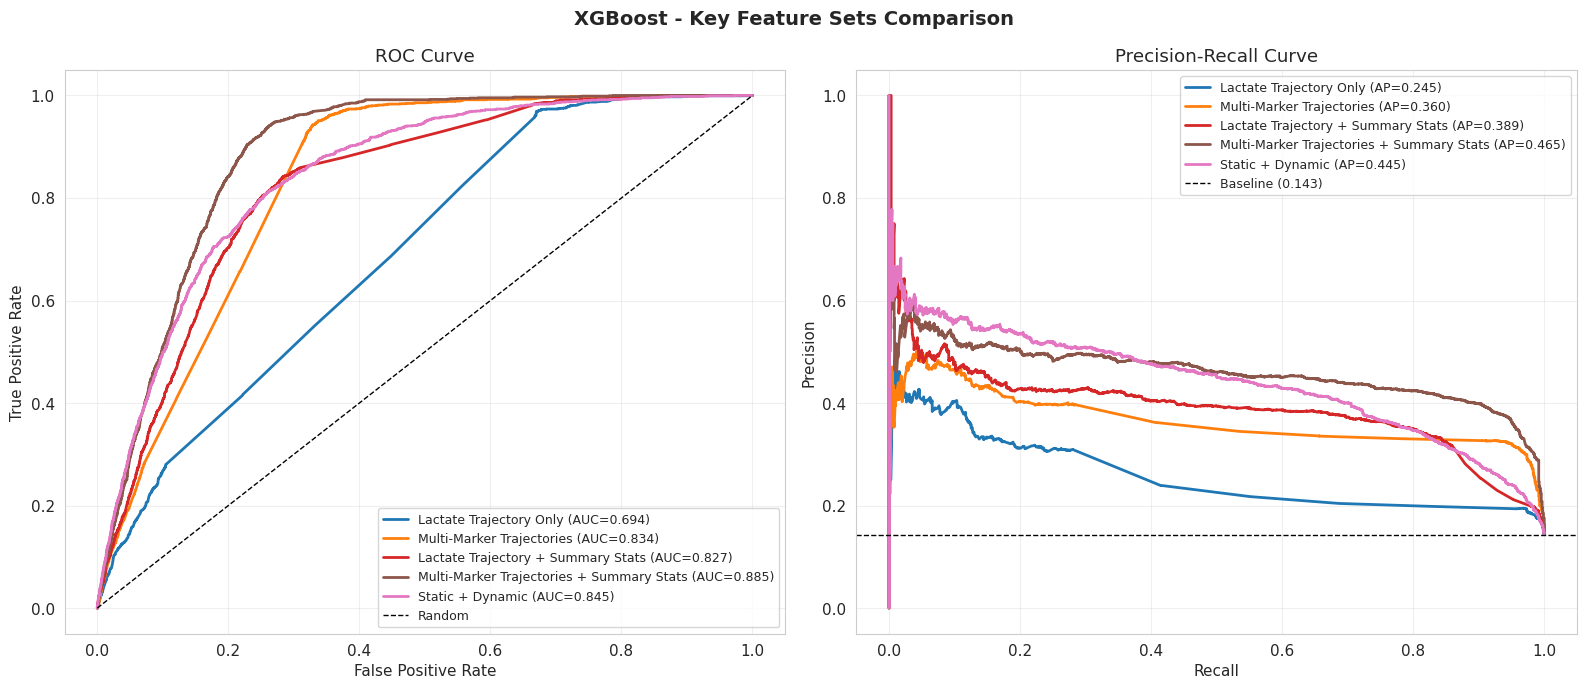

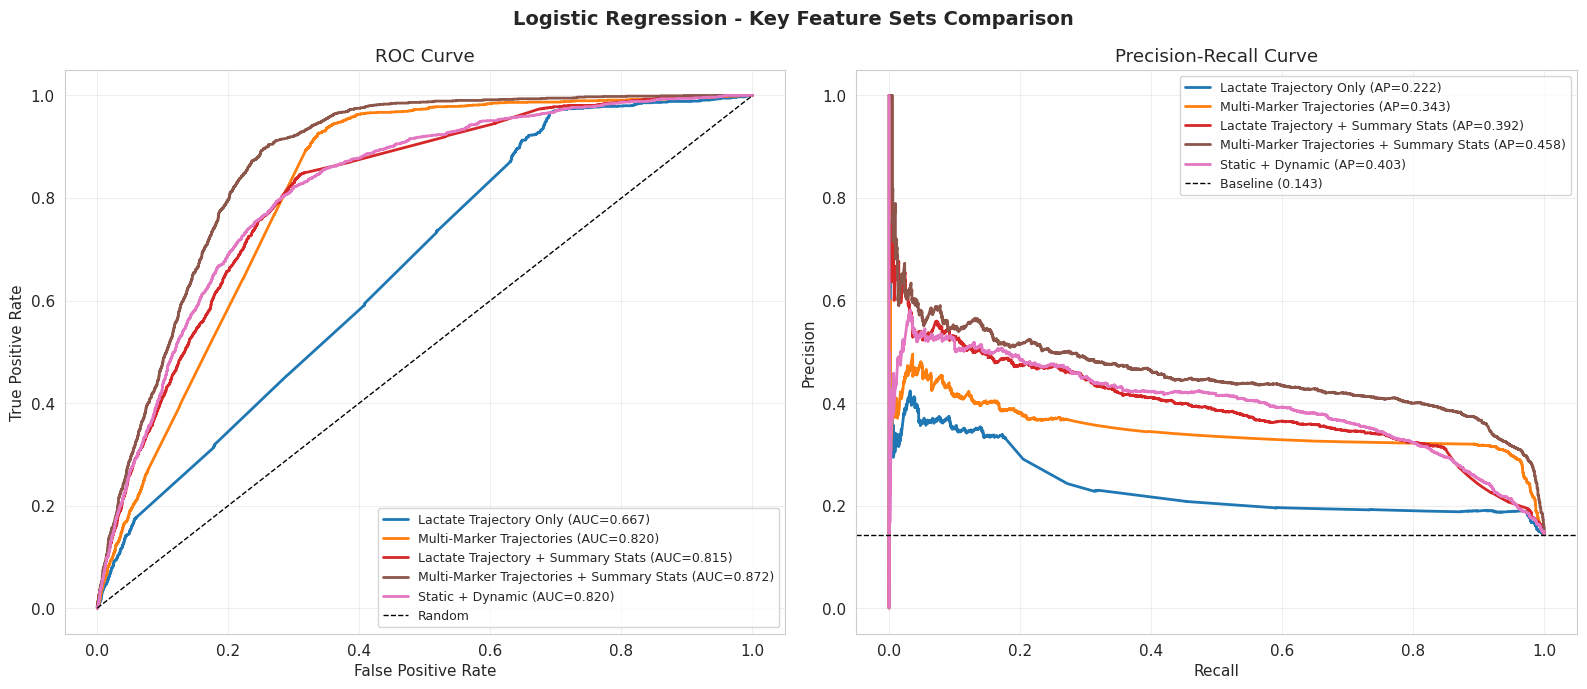

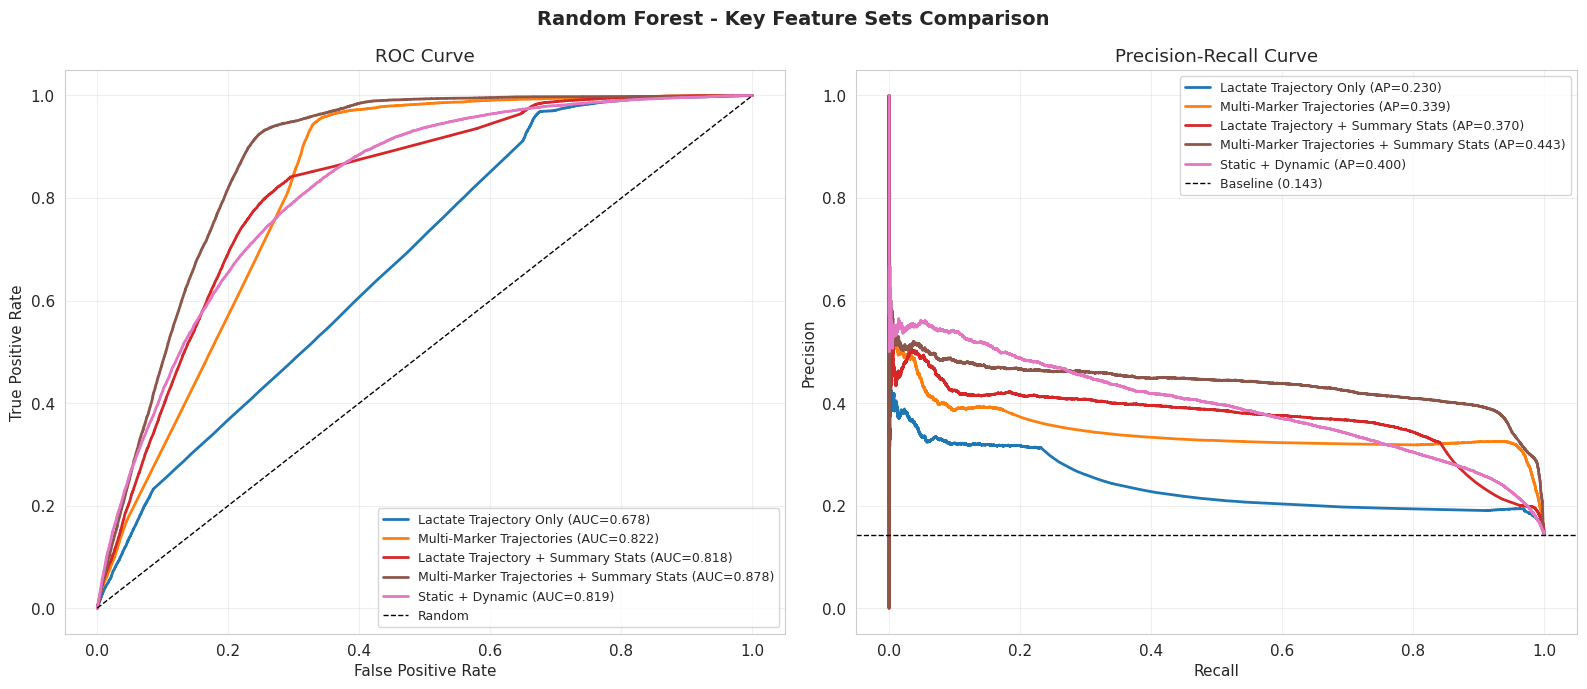

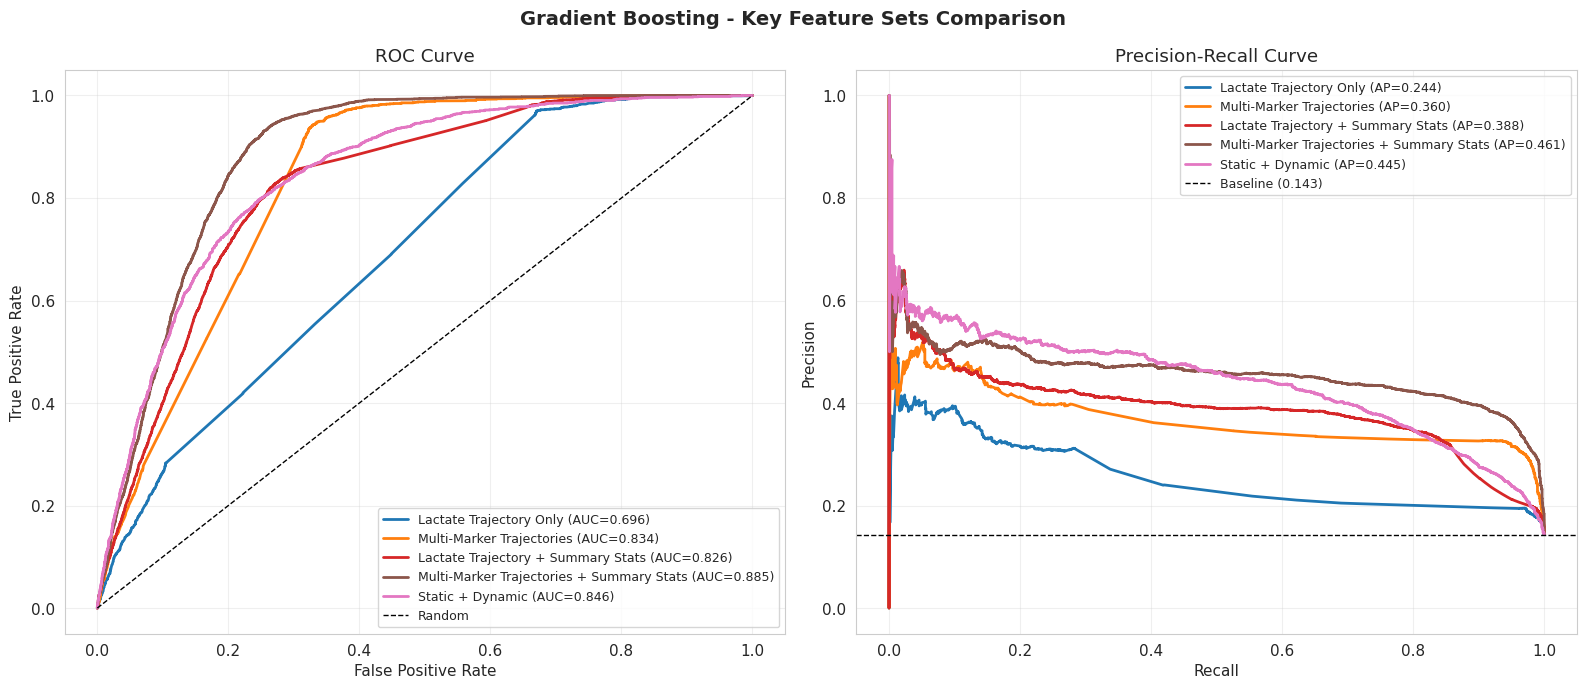

In [23]:
# ROC and PR curves for each model
for model_name in models_to_evaluate.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'{model_name} - Key Feature Sets Comparison', fontsize=14, fontweight='bold')
    
    # Select key feature sets to plot (to avoid overcrowding)
    key_sets = [
        'Lactate Trajectory Only',
        'Multi-Marker Trajectories',
        'Lactate Trajectory + Summary Stats',
        'Multi-Marker Trajectories + Summary Stats',
        'Static + Dynamic',
        'Lactate Trajectory + Summary Stats + Static + Dynamic',
        'Multi-Marker Trajectories + Summary Stats + Static + Dynamic'
    ]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(key_sets)))
    
    for idx, name in enumerate(key_sets):
        if name in results[model_name]:
            metrics = results[model_name][name]
            # ROC curve
            fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_pred'])
            auc = np.mean(metrics['roc_auc'])
            ax1.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[idx], linewidth=2)
            
            # PR curve
            precision, recall, _ = precision_recall_curve(metrics['y_true'], metrics['y_pred'])
            ap = np.mean(metrics['avg_precision'])
            ax2.plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=colors[idx], linewidth=2)
    
    # ROC plot formatting
    ax1.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # PR plot formatting
    baseline = y.mean()
    ax2.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})', linewidth=1)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Model Comparison Summary
print("Model Comparison Across All Feature Sets:")
print("="*100)

summary_data = []
for model_name in models_to_evaluate.keys():
    for feature_set_name, metrics in results[model_name].items():
        summary_data.append({
            'Model': model_name,
            'Feature Set': feature_set_name,
            'AUROC': np.mean(metrics['roc_auc']),
            'AUROC_std': np.std(metrics['roc_auc']),
            'AUPR': np.mean(metrics['avg_precision']),
            'AUPR_std': np.std(metrics['avg_precision'])
        })

summary_df = pd.DataFrame(summary_data)

# Show best performing configurations
print("\nTop 10 Configurations by AUROC:")
print(summary_df.nlargest(10, 'AUROC')[['Model', 'Feature Set', 'AUROC', 'AUPR']].to_string(index=False))

print("\n" + "="*100)
print("Best Model Per Key Feature Set:")
key_sets = [
    'Lactate Trajectory Only',
    'Multi-Marker Trajectories',
    'Static + Dynamic',
    'Lactate Trajectory + Summary Stats + Static + Dynamic',
    'Multi-Marker Trajectories + Summary Stats + Static + Dynamic'
]

Model Comparison Across All Feature Sets:

Top 10 Configurations by AUROC:
            Model                                                              Feature Set    AUROC     AUPR
          XGBoost             Static + Dynamic + Multi-Marker Trajectories + Summary Stats 0.942301 0.714729
Gradient Boosting             Static + Dynamic + Multi-Marker Trajectories + Summary Stats 0.941932 0.712320
Gradient Boosting Static + Dynamic + Multi-Marker Trajectories + Summary Stats (Bootstrap) 0.936769 0.704254
          XGBoost Static + Dynamic + Multi-Marker Trajectories + Summary Stats (Bootstrap) 0.936332 0.700646
          XGBoost                            Static + Dynamic + Multi-Marker Summary Stats 0.932049 0.681677
Gradient Boosting                            Static + Dynamic + Multi-Marker Summary Stats 0.931719 0.684624
          XGBoost                             Static + Dynamic + Multi-Marker Trajectories 0.928589 0.632263
Gradient Boosting                             Static 

IndexError: single positional indexer is out-of-bounds

✓ Saved: results/eicu/sepsis/comprehensive_boxplots_xgboost.png


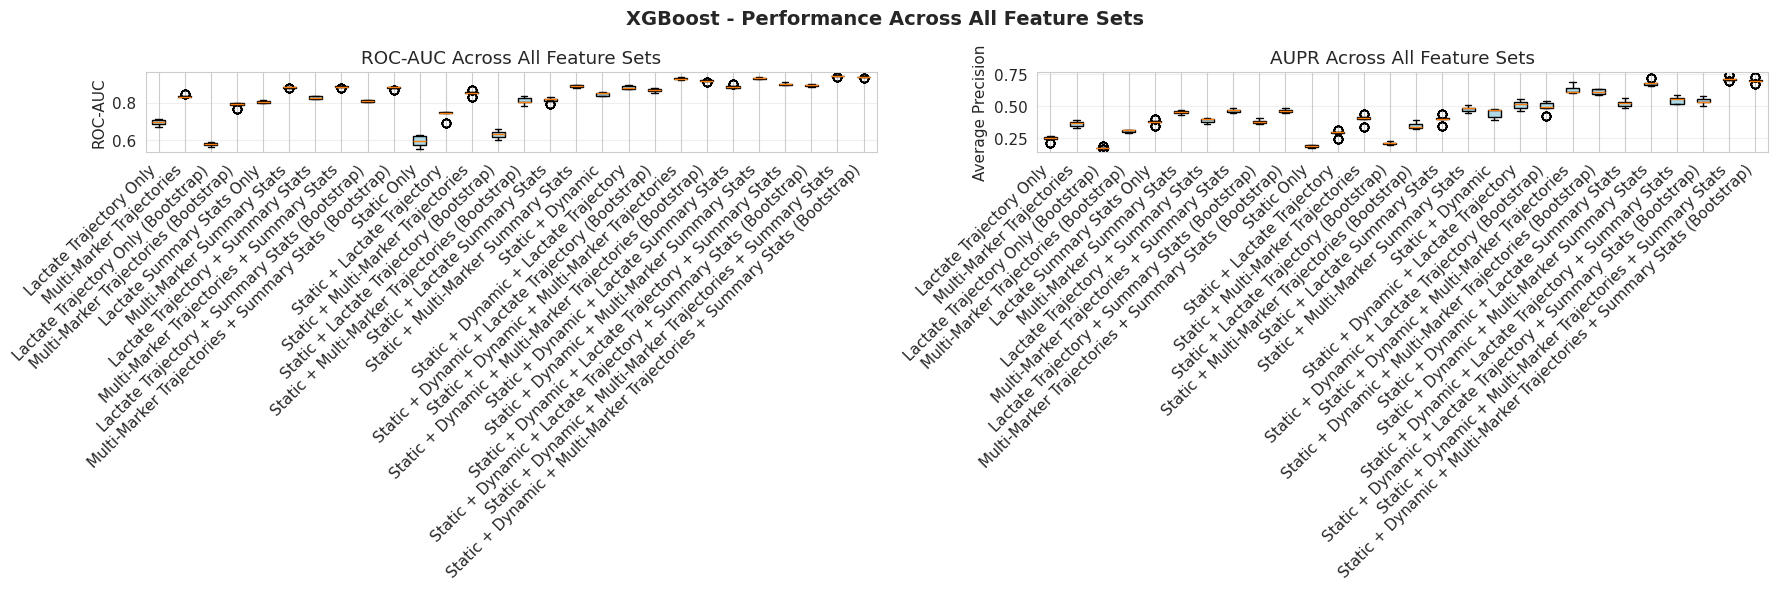

✓ Saved: results/eicu/sepsis/comprehensive_boxplots_logistic_regression.png


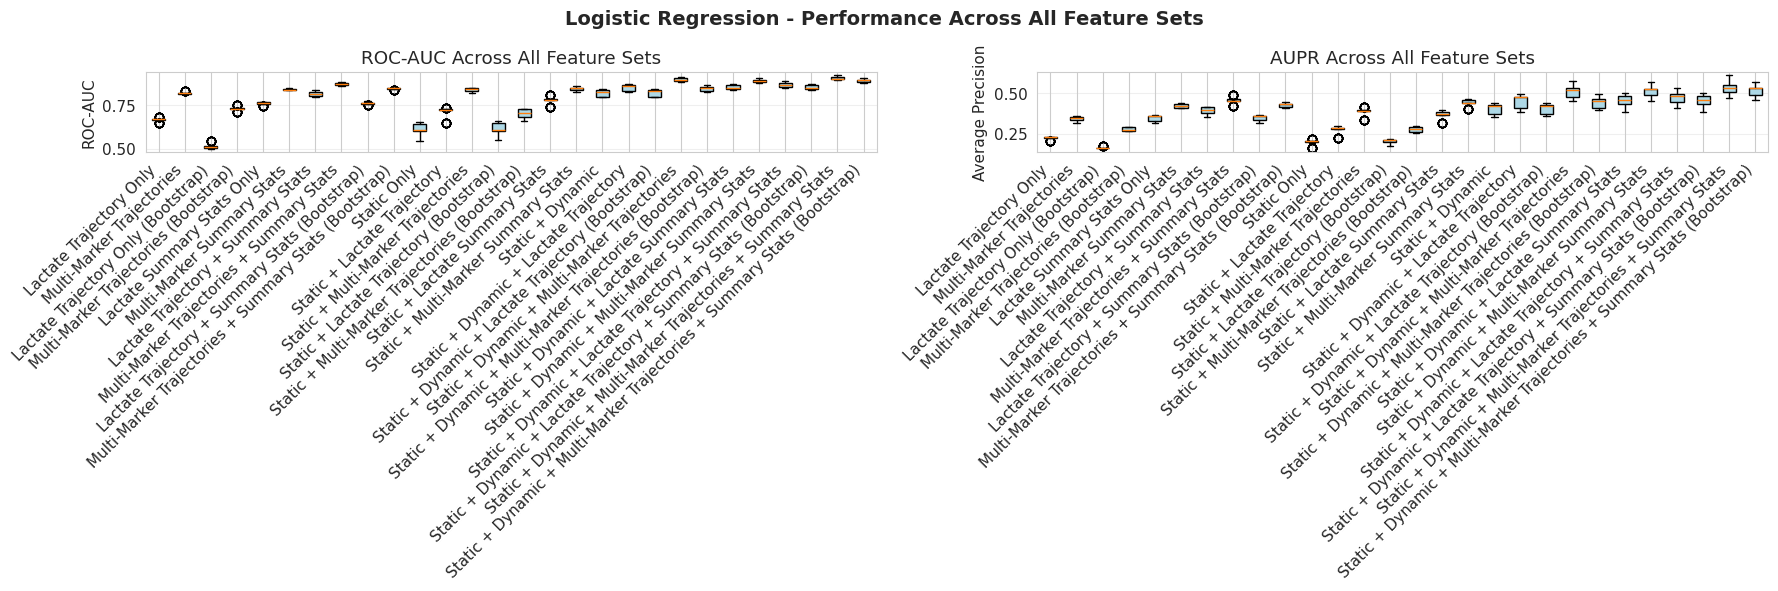

✓ Saved: results/eicu/sepsis/comprehensive_boxplots_random_forest.png


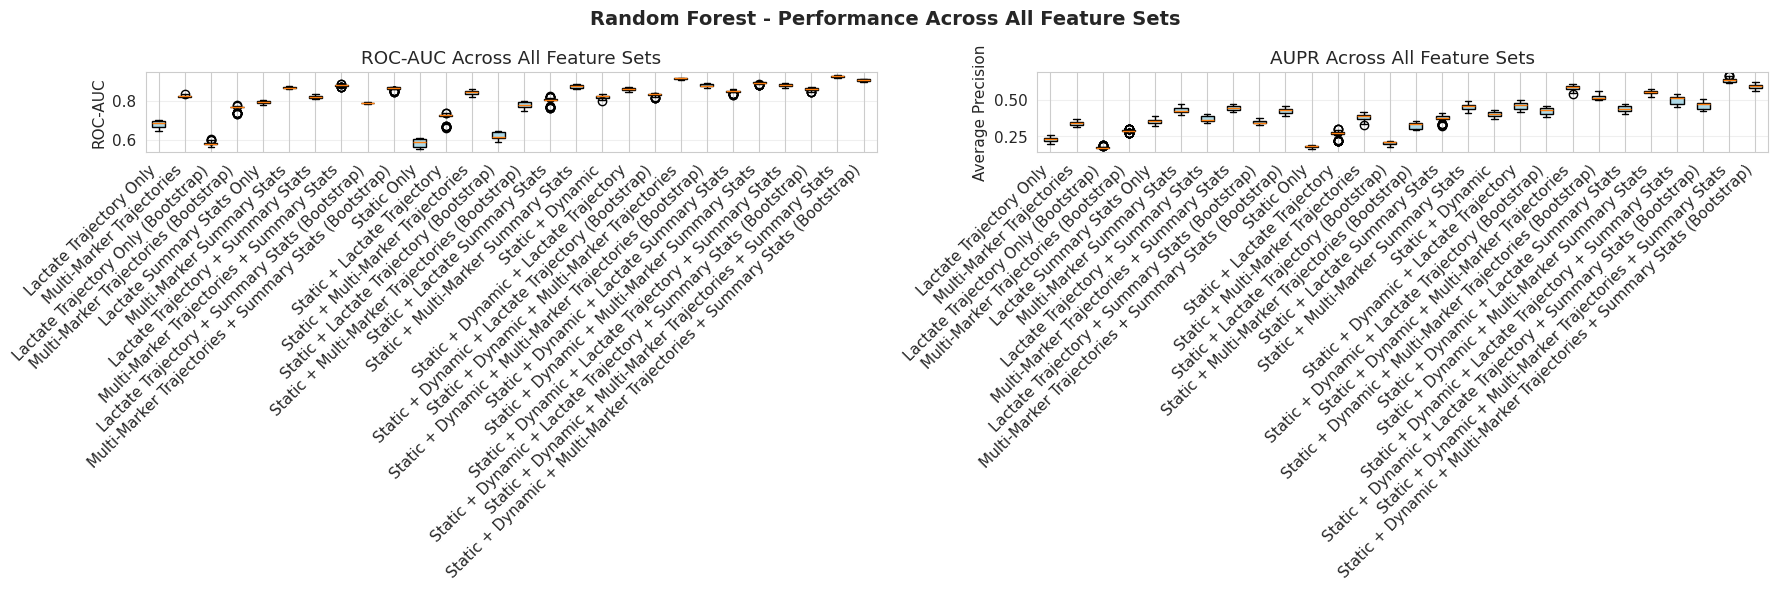

✓ Saved: results/eicu/sepsis/comprehensive_boxplots_gradient_boosting.png


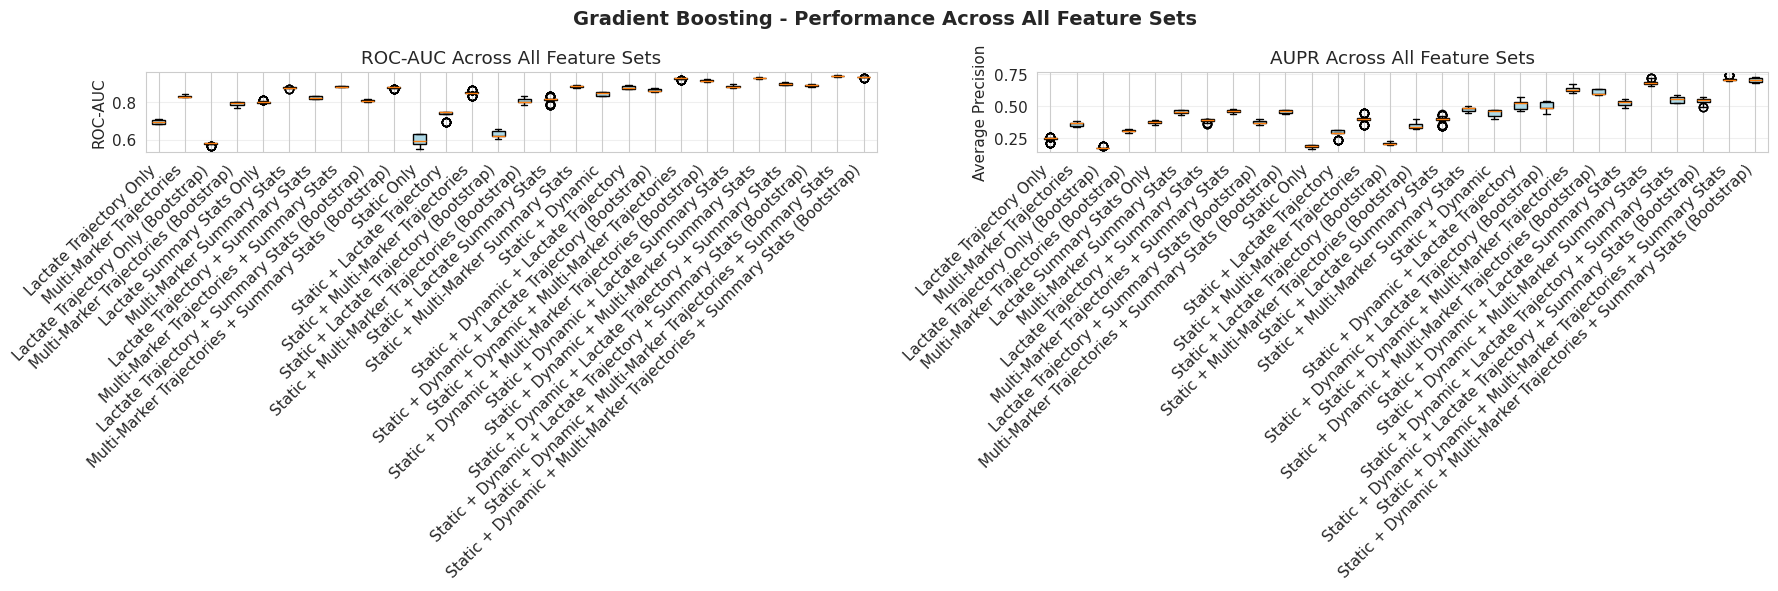

In [25]:
# Boxplots comparing all feature sets per model
for model_name in models_to_evaluate.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{model_name} - Performance Across All Feature Sets', fontsize=14, fontweight='bold')

    feature_set_names = list(results[model_name].keys())
    roc_data = [results[model_name][name]['roc_auc'] for name in feature_set_names]
    ap_data = [results[model_name][name]['avg_precision'] for name in feature_set_names]

    bp1 = ax1.boxplot(roc_data, labels=feature_set_names, patch_artist=True)
    ax1.set_ylabel('ROC-AUC')
    ax1.set_title('ROC-AUC Across All Feature Sets')
    ax1.set_xticklabels(feature_set_names, rotation=45, ha='right')
    ax1.grid(alpha=0.3, axis='y')

    bp2 = ax2.boxplot(ap_data, labels=feature_set_names, patch_artist=True)
    ax2.set_ylabel('Average Precision')
    ax2.set_title('AUPR Across All Feature Sets')
    ax2.set_xticklabels(feature_set_names, rotation=45, ha='right')
    ax2.grid(alpha=0.3, axis='y')

    for bp in [bp1, bp2]:
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')

    plt.tight_layout()
    plt.savefig(f'../../../results/eicu/sepsis/comprehensive_boxplots_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: results/eicu/sepsis/comprehensive_boxplots_{model_name.replace(' ', '_').lower()}.png")
    plt.show()

✓ Saved: results/eicu/sepsis/key_models_comparison_xgboost.png


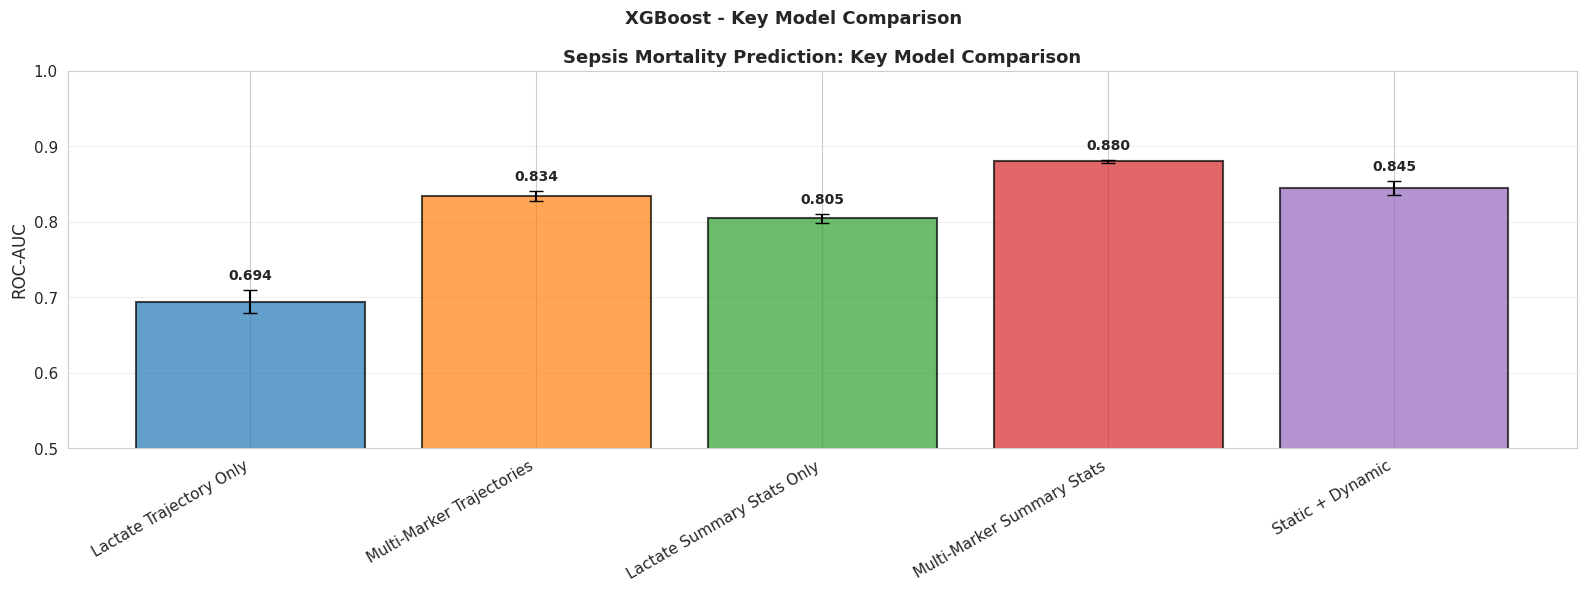

✓ Saved: results/eicu/sepsis/key_models_comparison_logistic_regression.png


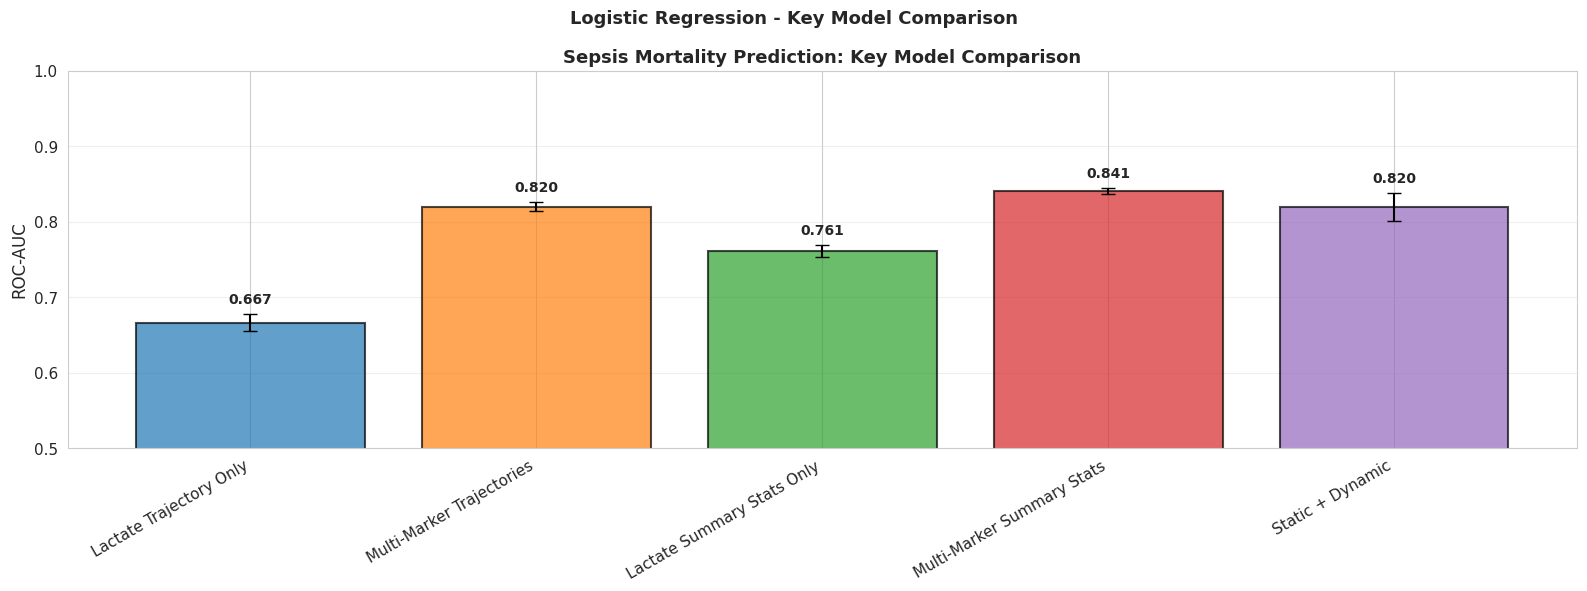

✓ Saved: results/eicu/sepsis/key_models_comparison_random_forest.png


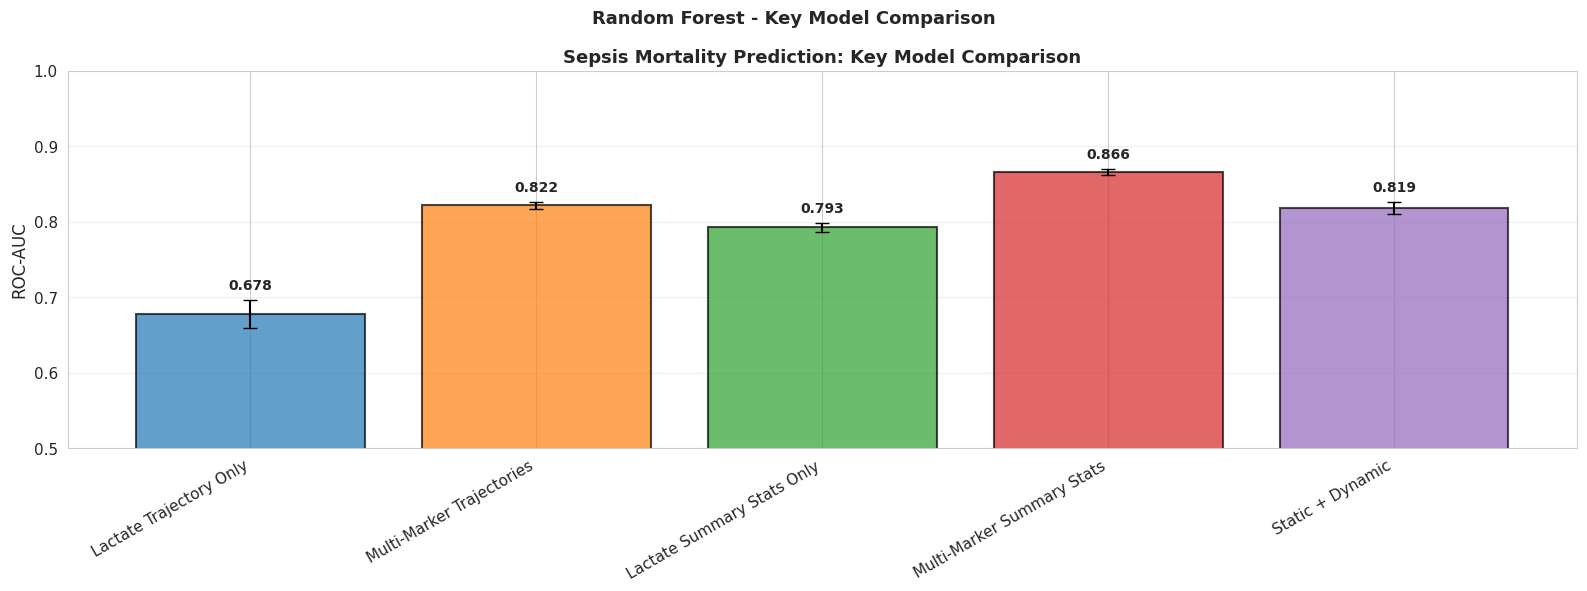

✓ Saved: results/eicu/sepsis/key_models_comparison_gradient_boosting.png


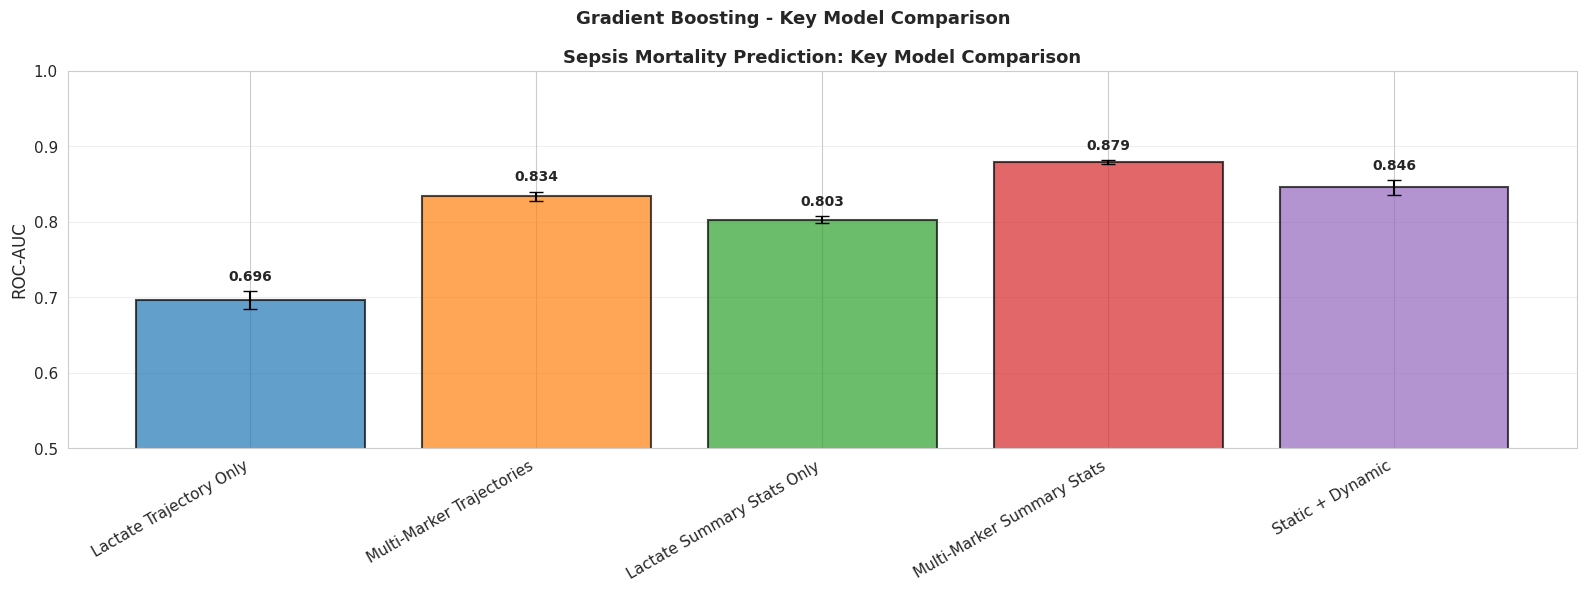

In [26]:
# Compare key models: Lactate vs Multi-Marker, Trajectory vs Summary vs Full (per model type)
for model_name in models_to_evaluate.keys():
    fig, ax = plt.subplots(figsize=(16, 6))
    fig.suptitle(f'{model_name} - Key Model Comparison', fontsize=13, fontweight='bold')

    # Select key models for comparison (matching MIMIC framework)
    key_models = {
        'Lactate Trajectory Only': results[model_name].get('Lactate Trajectory Only', None),
        'Multi-Marker Trajectories': results[model_name].get('Multi-Marker Trajectories', None),
        'Lactate Summary Stats Only': results[model_name].get('Lactate Summary Stats Only', None),
        'Multi-Marker Summary Stats': results[model_name].get('Multi-Marker Summary Stats', None),
        'Static + Dynamic': results[model_name].get('Static + Dynamic', None),
        'Lactate Traj + Summary + Static + Dynamic': results[model_name].get('Lactate Trajectory + Summary Stats + Static + Dynamic', None),
        'Multi-Marker Full Model': results[model_name].get('Multi-Marker Trajectories + Summary Stats + Static + Dynamic', None),
    }

    # Filter out None values
    key_models = {k: v for k, v in key_models.items() if v is not None}

    model_names = list(key_models.keys())
    aurocs = [np.mean(metrics['roc_auc']) for metrics in key_models.values()]
    auroc_stds = [np.std(metrics['roc_auc']) for metrics in key_models.values()]

    colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'][:len(model_names)]

    bars = ax.bar(model_names, aurocs, yerr=auroc_stds, color=colors_bar, 
                  edgecolor='black', linewidth=1.5, capsize=5, alpha=0.7)

    # Add value labels on bars
    for bar, val, std in zip(bars, aurocs, auroc_stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel('ROC-AUC', fontsize=12)
    ax.set_title('Sepsis Mortality Prediction: Key Model Comparison', fontsize=13, fontweight='bold')
    ax.set_ylim([0.5, 1.0])
    ax.set_xticklabels(model_names, rotation=30, ha='right')
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f'../../../results/eicu/sepsis/key_models_comparison_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: results/eicu/sepsis/key_models_comparison_{model_name.replace(' ', '_').lower()}.png")
    plt.show()